## 6. Random Forest Classifier

### 6.1 Packages importeren 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

from sklearn.model_selection import (
    train_test_split, cross_val_score, GridSearchCV
)
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

from preprocessing import(
    my_preprocessor,
    my_tokenizer,
)
from helpfuncties import load_dataset

### 6.2 Dataset inladen 

In [2]:
df = load_dataset()   
X = df["Omschrijving"]
y = df["Product"]

print("Dataset shape:", df.shape)

Dataset shape: (14887, 2)


### 6.3 Train-Test Split

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3,
                                                    random_state=42, stratify=y)

### 6.4 Vocab size experiment 

In [ ]:
vocab_sizes = [2000, 2500, 3000, 3500, 5000, 8000, 10000, 15000]
results = []

# Alle tokens verzamelen
all_tokens = []
for text in X_train:
    all_tokens.extend(my_tokenizer(text))

freq = Counter(all_tokens)

for size in vocab_sizes:
    print(f"Testen met vocab_size = {size}")

    top_words_size = [w.lower() for w, c in freq.most_common(size)]

    tfidf_tmp = TfidfVectorizer(
        preprocessor=my_preprocessor,
        tokenizer=my_tokenizer,
        token_pattern=None,
        analyzer="word",
        vocabulary=top_words_size,
        sublinear_tf=True
    )

    rf_tmp = RandomForestClassifier(
        random_state=42,
        n_jobs=-1,
        n_estimators=300,
        max_depth=30,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features="sqrt"
    )

    pipe_tmp = Pipeline([
        ("tfidf", tfidf_tmp),
        ("rf", rf_tmp)
    ])

    scores = cross_val_score(
        pipe_tmp, X_train, y_train,
        cv=5,
        scoring="f1_weighted",
        n_jobs=-1
    )

    mean_score = scores.mean()
    results.append((size, mean_score))

    print(f" --> F1-weighted: {mean_score:.4f}\n")

best_vocab_size, best_score = max(results, key=lambda x: x[1])

print("Beste vocabulary size:", best_vocab_size)
print("Beste baseline F1:", best_score)

Vocabulary size experiment gestart...

Testen met vocab_size = 3000
 → F1-weighted: 0.8022

Testen met vocab_size = 5000
 → F1-weighted: 0.7960

Testen met vocab_size = 8000
 → F1-weighted: 0.7878

Testen met vocab_size = 10000
 → F1-weighted: 0.7834

Testen met vocab_size = 15000
 → F1-weighted: 0.7720

Beste vocabulary size: 3000
Beste baseline F1: 0.8022325614535


### 6.5 Definitieve vocab

In [5]:
best_top_words = [w.lower() for w, c in freq.most_common(best_vocab_size)]
best_top_words = list(dict.fromkeys(best_top_words))

print("Aantal woorden in beste vocab:", len(best_top_words))

Aantal woorden in beste vocab: 3000


### 6.6 Definitieve TF-IDF + Random Forest Pipeline

In [6]:
tfidf_final = TfidfVectorizer(
    preprocessor=my_preprocessor,
    tokenizer=my_tokenizer,
    token_pattern=None,
    analyzer="word",
    vocabulary=best_top_words,
    sublinear_tf=True
)

rf = RandomForestClassifier(
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_pipeline = Pipeline([
    ("tfidf", tfidf_final),
    ("rf", rf)
])

### 6.7 GridsearchCV

In [7]:
param_grid = {
    "rf__n_estimators": [200, 300, 500],
    "rf__max_depth": [20, 30, 40, 60],
    "rf__min_samples_split": [2, 4],
    "rf__min_samples_leaf": [1, 2],
    "rf__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid,
    cv=3,
    scoring="f1_macro",
    verbose=2,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
print("\nBeste parameters:", grid_search.best_params_)

Fitting 3 folds for each of 96 candidates, totalling 288 fits

Beste parameters: {'rf__max_depth': 60, 'rf__max_features': 'sqrt', 'rf__min_samples_leaf': 2, 'rf__min_samples_split': 2, 'rf__n_estimators': 500}


### 6.8 Cross-validation (betrouwbaarheid testen)

In [8]:
scores = cross_val_score(
    best_model,
    X_train, y_train,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1
)

print("Gemiddelde CV F1:", scores.mean())
print("CV scores:", scores)

Gemiddelde CV F1: 0.8302000809905291
CV scores: [0.8277281  0.83080666 0.82955078 0.81836912 0.84454575]


### 6.9 Evaluatie Modelprestaties 

#### 6.9.1 Voorspellingen

In [9]:
y_pred_test = best_model.predict(X_test)
y_proba_test = best_model.predict_proba(X_test)
y_pred_train = best_model.predict(X_train)

#### 6.9.2 Totale metrics

In [10]:
test_accuracy = accuracy_score(y_test, y_pred_test)
test_f1 = f1_score(y_test, y_pred_test, average='weighted')
train_accuracy = accuracy_score(y_train, y_pred_train)
train_f1 = f1_score(y_train, y_pred_train, average='weighted')

print(f'Test Accuracy RF: {test_accuracy:.3f}')
print(f"Test F1 RF: {test_f1:.3f}")
print(f'Train Accuracy RF: {train_accuracy:.3f}')
print(f"Train F1 RF: {train_f1:.3f}")

Test Accuracy RF: 0.829
Test F1 RF: 0.826
Train Accuracy RF: 0.971
Train F1 RF: 0.971


#### 6.9.3 Classification report

In [11]:
print("\nClassification report Testset:\n")
print(classification_report(y_test, y_pred_test))


Classification report Testset:

                    precision    recall  f1-score   support

      Bankrekening       0.83      0.80      0.82       447
Consumentenkrediet       0.78      0.51      0.61       284
        Creditcard       0.78      0.77      0.77       565
         Hypotheek       0.89      0.94      0.92       994
           Incasso       0.83      0.83      0.83      1229
Kredietregistratie       0.80      0.85      0.83       948

          accuracy                           0.83      4467
         macro avg       0.82      0.78      0.80      4467
      weighted avg       0.83      0.83      0.83      4467



In [12]:
print("\nClassification report Trainset:\n")
print(classification_report(y_train, y_pred_train))


Classification report Trainset:

                    precision    recall  f1-score   support

      Bankrekening       0.97      0.99      0.98      1042
Consumentenkrediet       0.97      0.98      0.98       663
        Creditcard       0.98      0.96      0.97      1319
         Hypotheek       0.99      0.99      0.99      2320
           Incasso       0.97      0.95      0.96      2865
Kredietregistratie       0.95      0.97      0.96      2211

          accuracy                           0.97     10420
         macro avg       0.97      0.97      0.97     10420
      weighted avg       0.97      0.97      0.97     10420



#### 6.9.4 Confusion Matrix

[[ 359    3   46   16   13   10]
 [  12  144   18   29   53   28]
 [  28    3  435    7   53   39]
 [  10    4    6  935   21   18]
 [  18   19   25   42 1022  103]
 [   6   12   29   16   75  810]]


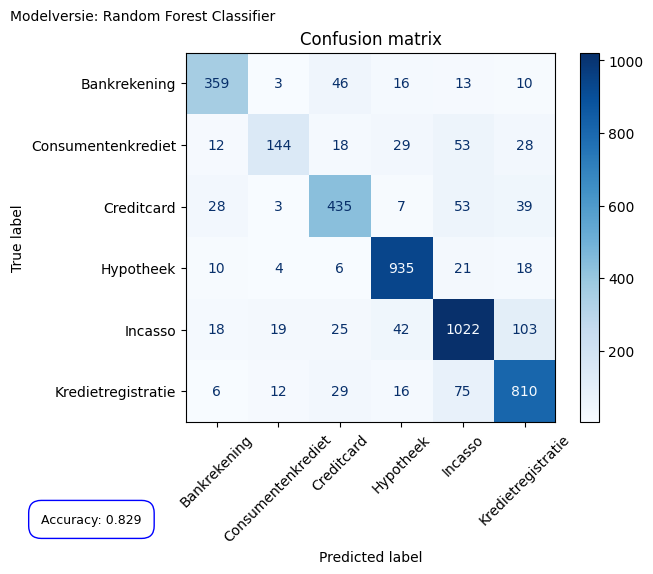

In [13]:
cm = confusion_matrix(y_test, y_pred_test)
print(cm)

disp = ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_test,
    cmap='Blues'
)
plt.xticks(rotation=45)
plt.title('Confusion matrix')
plt.suptitle("Modelversie: Random Forest Classifier", fontsize=10, x=0.1, y=0.97) # ! naam aanpassen per modelversie
plt.figtext(0.02, -0.1, f"Accuracy: {test_accuracy:.3f}", ha='center', fontsize=9, color='black', bbox=dict(facecolor='none', edgecolor='blue', boxstyle='round,pad=1'))
plt.savefig("afbeeldingen/confusion_matrix_random_forest.png", dpi=300, bbox_inches='tight') # ! naam aanpassen per modelversie
plt.show()

#### 6.9.5 AUC-score (multiclass)

In [14]:
auc_rf = roc_auc_score(y_test, y_proba_test, multi_class='ovr')
print(f"AUC Random Forest Classifier: {auc_rf:.3f}")

AUC Random Forest Classifier: 0.962
